## Importing Required Libraries

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings("ignore")
from time import time
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
import optuna
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data=pd.read_excel(r"D:\projects\activation_energy_prediction\G_models\Ga DelG dataset for prediction.xlsx")

In [3]:
num_reactions = 153
# Create an array of indices representing the reactions
reaction_indices = np.arange(num_reactions)

# Split the reactions into train and test sets
train_indices, test_indices = train_test_split(reaction_indices, test_size=0.3,random_state=42)

# Initialize empty lists to hold train and test data
train_data=pd.DataFrame()
test_data =pd.DataFrame()

# Populate train and test data using the selected indices

for i in range(51):
    for idx in train_indices:
        train_data=train_data.append(data.iloc[idx+num_reactions*i],ignore_index=True)
    for idx in test_indices:
        test_data=test_data.append(data.iloc[idx+num_reactions*i],ignore_index=True)

In [4]:
## Ga Model
train=train_data.drop(['Unnamed: 0',"Reactions","Reactant 1","Reactant 2","Product 1","Product 2","Del G","Del E"],axis=1)
test=test_data.drop(['Unnamed: 0',"Reactions","Reactant 1","Reactant 2","Product 1","Product 2","Del G","Del E"],axis=1)
y_train=train[['Ga']]
x_train=train.drop(["Ga"],axis=1)
y_test=test[['Ga']]
x_test=test.drop(["Ga"],axis=1)
cor = x_train.corr('pearson')
# get upper triangle of correlation matrix
upper = cor.where(np.triu(np.ones(cor.shape), k=1).astype(np.bool))

# find features with correlation greater than 0.90
to_drop = [column for column in upper.columns if any(upper[column] > 0.90)]

# drop highly correlated features
x_train.drop(to_drop, axis=1, inplace=True)
x_test.drop(to_drop, axis=1, inplace=True)

In [5]:
model=Ridge(alpha=9.958498584649295)
model.fit(x_train,y_train)
preds=model.predict(x_test)
train_pred=model.predict(x_train)
train_r2=r2_score(y_train,train_pred)
test_r2=r2_score(y_test,preds)
print(train_r2)
print(test_r2)
print(mean_absolute_error(y_test,preds))
print(mean_absolute_error(y_train,train_pred))

0.9797631804836894
0.9771757950961939
0.04939958720333505
0.03793167627267559


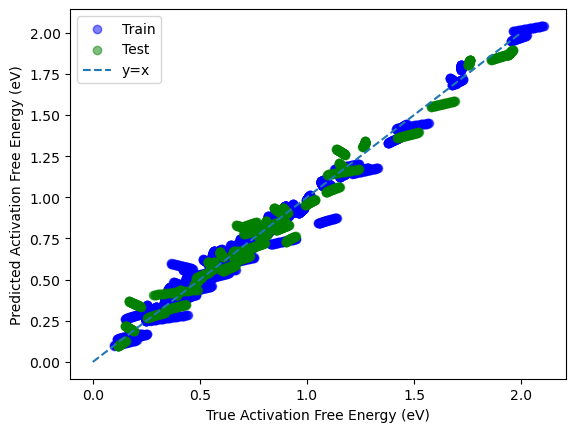

In [7]:
# Parity Plot
plt.scatter(y_train,train_pred,c="blue",alpha=0.5)
plt.scatter(y_test,preds,c="green",alpha=0.5)
plt.xlabel('True Activation Free Energy (eV)')
plt.ylabel('Predicted Activation Free Energy (eV)')
parity_x = np.linspace(0,2,100)
plt.plot(parity_x,parity_x,'--')
plt.legend(["Train","Test","y=x"])
plt.savefig('Parity Ga.pdf')
plt.show()

In [13]:
#pickle save model
import pickle
pickle.dump(model, open('Ga19oct.pkl','wb'))

## DelG

In [8]:
train=train_data.drop(['Unnamed: 0','Reactions',"Reactant 1","Reactant 2","Product 1","Product 2","Ga","Ea"],axis=1)
test=test_data.drop(['Unnamed: 0','Reactions',"Reactant 1","Reactant 2","Product 1","Product 2","Ga","Ea"],axis=1)
y_train=train[['Del G']]
x_train=train.drop(["Del G"],axis=1)

y_test=test[['Del G']]
x_test=test.drop(["Del G"],axis=1)

In [9]:
x_train=x_train[['T', 'Del E', 'nC(R1)', 'nC(R2)', 'nC(P2)', 'nO(R1)', 'nO(R2)', 'nO(P1)',
       'nO(P2)', 'nH(R1)', 'nH(R2)', 'nH(P2)', 'Cn-H', 'C-O', 'C-C',
       'numCO_Hbond', 'numC_OHbond', 'MolWt_R1', 'MolWt_P1', 'num_terC_R1',
       'num_terC_R2', 'num_terC_P1', 'num_terC_P2', 'num_secC_R1',
       'num_secC_R2', 'num_secC_P1', 'num_priC_R1', 'num_priC_R2',
       'num_priC_P1', 'num_priC_P2']]
x_test=x_test[['T', 'Del E', 'nC(R1)', 'nC(R2)', 'nC(P2)', 'nO(R1)', 'nO(R2)', 'nO(P1)',
       'nO(P2)', 'nH(R1)', 'nH(R2)', 'nH(P2)', 'Cn-H', 'C-O', 'C-C',
       'numCO_Hbond', 'numC_OHbond', 'MolWt_R1', 'MolWt_P1', 'num_terC_R1',
       'num_terC_R2', 'num_terC_P1', 'num_terC_P2', 'num_secC_R1',
       'num_secC_R2', 'num_secC_P1', 'num_priC_R1', 'num_priC_R2',
       'num_priC_P1', 'num_priC_P2']]

In [10]:
model=Ridge(alpha=9.994313161326836)
model.fit(x_train,y_train)
preds=model.predict(x_test)
train_pred=model.predict(x_train)
train_r2=r2_score(y_train,train_pred)
test_r2=r2_score(y_test,preds)
print(train_r2)
print(test_r2)
print(mean_absolute_error(y_test,preds))
print(mean_absolute_error(y_train,train_pred))

0.9833393620052565
0.9796893628077186
0.06445171058055384
0.055746448604974935


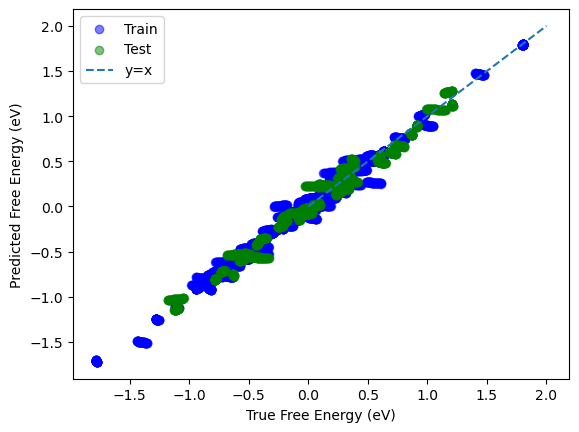

In [33]:
# Parity Plot
plt.scatter(y_train,train_pred,c="blue",alpha=0.5)
plt.scatter(y_test,preds,c="green",alpha=0.5)
plt.xlabel('True Free Energy (eV)')
plt.ylabel('Predicted Free Energy (eV)')
parity_x = np.linspace(0,2,100)
plt.plot(parity_x,parity_x,'--')
plt.legend(["Train","Test","y=x"])
# #write r2 inside figure
# plt.text(0,-1, 'Train $R^2$ :0.983', fontsize = 12,  
#          bbox = dict(facecolor = 'green', alpha = 0.5)) 
# plt.text(0,-1.5, 'Test $R^2$ :0.983', fontsize = 12,  
#          bbox = dict(facecolor = 'green', alpha = 0.5)) 
plt.savefig('Parity DelG.pdf')
plt.show()

In [19]:
#pickle save model
pickle.dump(model, open('DelG19oct.pkl','wb'))

## Predicting

In [21]:
data=pd.read_csv(r"D:\projects\activation_energy_prediction\E_models\predicted306_unscaled.csv")
data

,Unnamed: 0,Del E,nC(R1),nC(R2),nC(P2),nO(R1),nO(R2),nO(P1),nO(P2),nH(R1),...,Product₂474,Reactant₁795,Reactant₂795,Product₁795,Product₂795,Reactant₁1005,Reactant₂1005,Product₁1005,Product₂1005,Ea
0,0,0.39,1,0,0,2,0,2,0,0,...,0,0,0,0,0,0,0,0,0,1.280162
1,1,-0.19,1,0,0,2,0,1,1,1,...,0,0,0,0,1,0,0,0,0,0.614162
2,2,1.37,1,1,0,1,1,2,0,0,...,0,0,0,0,0,0,0,0,0,1.361463
3,3,-0.73,2,0,0,2,0,1,1,0,...,0,0,0,0,0,0,0,0,0,0.670744
4,4,-0.27,2,0,0,2,0,2,0,0,...,0,0,0,0,0,0,0,0,0,0.510737
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
301,301,-0.81,1,0,0,2,0,2,0,2,...,0,0,0,0,0,0,0,1,0,0.499849
302,302,0.21,1,0,0,2,0,2,0,3,...,0,0,0,0,0,0,0,0,0,1.063642
303,303,-0.05,1,1,1,2,1,2,1,2,...,0,0,0,0,0,0,0,1,0,0.719700
304,304,0.31,1,1,1,2,1,2,1,2,...,0,0,0,0,0,1,0,1,0,0.858434


In [23]:
data_153=data[['Del E','Ea', 'nC(R1)', 'nC(R2)', 'nC(P2)', 'nO(R1)', 'nO(R2)', 'nO(P1)',
       'nO(P2)', 'nH(R1)', 'nH(R2)', 'nH(P2)', 'Cn-H', 'C-O', 'C-C',
       'numCO_Hbond', 'numC_OHbond', 'MolWt_R1', 'MolWt_P1', 'num_terC_R1',
       'num_terC_R2', 'num_terC_P1', 'num_terC_P2', 'num_secC_R1',
       'num_secC_R2', 'num_secC_P1', 'num_priC_R1', 'num_priC_R2',
       'num_priC_P1', 'num_priC_P2']]

In [24]:
##loading model
import pickle
import numpy as np
modelGa=pickle.load(open('Ga19Oct.pkl','rb'))
modelDelG=pickle.load(open('DelG19Oct.pkl','rb'))
Ga=pd.DataFrame()
DelG=pd.DataFrame()

In [26]:
x_predicGa=data_153.drop("Del E",axis=1)
x_predicDelG=data_153.drop("Ea",axis=1)
for i in np.arange(300,950,50):
    x_predicGa["Tempearture"+str(i)]=i
    first_column = x_predicGa.pop('Tempearture'+str(i))
    x_predicGa.insert(0, 'Tempearture'+str(i), first_column)
    x_predicDelG["Tempearture"+str(i)]=i
    first_column = x_predicDelG.pop('Tempearture'+str(i))
    x_predicDelG.insert(0, 'Tempearture'+str(i), first_column)
    Ga["Ga"+str(i)]=modelGa.predict(x_predicGa).tolist()
    DelG["DelG"+str(i)]=modelDelG.predict(x_predicDelG).tolist()
    x_predicGa.drop("Tempearture"+str(i),axis=1,inplace=True)
    x_predicDelG.drop("Tempearture"+str(i),axis=1,inplace=True)

In [28]:
Ga.to_excel(r"C:\Users\USER\Downloads\New306PredictedGa19oct.xlsx")
DelG.to_excel(r"C:\Users\USER\Downloads\New306PredictedDelG19oct.xlsx")

## Predicting 9k 27 Oct

In [4]:
data=pd.read_csv(r"C:\Users\USER\Downloads\predicted9k_27oct.csv")

In [5]:
data_153=data[['Del E','Ea', 'nC(R1)', 'nC(R2)', 'nC(P2)', 'nO(R1)', 'nO(R2)', 'nO(P1)',
       'nO(P2)', 'nH(R1)', 'nH(R2)', 'nH(P2)', 'Cn-H', 'C-O', 'C-C',
       'numCO_Hbond', 'numC_OHbond', 'MolWt_R1', 'MolWt_P1', 'num_terC_R1',
       'num_terC_R2', 'num_terC_P1', 'num_terC_P2', 'num_secC_R1',
       'num_secC_R2', 'num_secC_P1', 'num_priC_R1', 'num_priC_R2',
       'num_priC_P1', 'num_priC_P2']]

In [6]:
##loading model
import pickle
import numpy as np
modelGa=pickle.load(open('Ga19Oct.pkl','rb'))
modelDelG=pickle.load(open('DelG19Oct.pkl','rb'))
Ga=pd.DataFrame()
DelG=pd.DataFrame()

In [9]:
x_predicGa=data_153.drop("Del E",axis=1)
x_predicDelG=data_153.drop("Ea",axis=1)
for i in np.arange(300,950,50):
    x_predicGa["T"]=i
    first_column = x_predicGa.pop('T')
    x_predicGa.insert(0, 'T', first_column)
    x_predicDelG["T"]=i
    first_column = x_predicDelG.pop('T')
    x_predicDelG.insert(0, 'T', first_column)
    Ga["Ga"+str(i)]=modelGa.predict(x_predicGa).tolist()
    DelG["DelG"+str(i)]=modelDelG.predict(x_predicDelG).tolist()
    x_predicGa.drop("T",axis=1,inplace=True)
    x_predicDelG.drop("T",axis=1,inplace=True)

In [10]:
for i in np.arange(300,950,50):
    for index in Ga.index:
        Ga["Ga"+str(i)][index]=str(Ga["Ga"+str(i)][index])
        Ga["Ga"+str(i)][index]=Ga["Ga"+str(i)][index].replace(']','')
        Ga["Ga"+str(i)][index]=Ga["Ga"+str(i)][index].replace('[','')
    for index in DelG.index:
        DelG["DelG"+str(i)][index]=str(DelG["DelG"+str(i)][index])
        DelG["DelG"+str(i)][index]=DelG["DelG"+str(i)][index].replace(']','')
        DelG["DelG"+str(i)][index]=DelG["DelG"+str(i)][index].replace('[','')    

In [15]:
Ga=pd.concat([data.iloc[:,1:6],Ga],axis=1)
DelG=pd.concat([data.iloc[:,1:6],DelG],axis=1)

In [18]:
Ga.to_excel("9k_PredictedGa27oct.xlsx")
DelG.to_excel("9k_PredictedDelG27oct.xlsx")

## Predicting 9k 

In [2]:
data=pd.read_csv(r"D:\projects\activation_energy_prediction\ML\predicted9k_1Dec.csv")

In [3]:
data_153=data[['Del E','Ea', 'nC(R1)', 'nC(R2)', 'nC(P2)', 'nO(R1)', 'nO(R2)', 'nO(P1)',
       'nO(P2)', 'nH(R1)', 'nH(R2)', 'nH(P2)', 'Cn-H', 'C-O', 'C-C',
       'numCO_Hbond', 'numC_OHbond', 'MolWt_R1', 'MolWt_P1', 'num_terC_R1',
       'num_terC_R2', 'num_terC_P1', 'num_terC_P2', 'num_secC_R1',
       'num_secC_R2', 'num_secC_P1', 'num_priC_R1', 'num_priC_R2',
       'num_priC_P1', 'num_priC_P2']]

In [4]:
##loading model
import pickle
import numpy as np
modelGa=pickle.load(open("D:\projects\\activation_energy_prediction\G_models\Ga19oct.pkl",'rb'))
modelDelG=pickle.load(open("D:\projects\\activation_energy_prediction\G_models\DelG19oct.pkl",'rb'))
Ga=pd.DataFrame()
DelG=pd.DataFrame()

In [5]:
x_predicGa=data_153.drop("Del E",axis=1)
x_predicDelG=data_153.drop("Ea",axis=1)
for i in np.arange(300,950,50):
    x_predicGa["Tempearture"+str(i)]=i
    first_column = x_predicGa.pop('Tempearture'+str(i))
    x_predicGa.insert(0, 'Tempearture'+str(i), first_column)
    x_predicDelG["Tempearture"+str(i)]=i
    first_column = x_predicDelG.pop('Tempearture'+str(i))
    x_predicDelG.insert(0, 'Tempearture'+str(i), first_column)
    Ga["Ga"+str(i)]=modelGa.predict(x_predicGa).tolist()
    DelG["DelG"+str(i)]=modelDelG.predict(x_predicDelG).tolist()
    x_predicGa.drop("Tempearture"+str(i),axis=1,inplace=True)
    x_predicDelG.drop("Tempearture"+str(i),axis=1,inplace=True)

In [6]:
for i in np.arange(300,950,50):
    for index in Ga.index:
        Ga["Ga"+str(i)][index]=str(Ga["Ga"+str(i)][index])
        Ga["Ga"+str(i)][index]=Ga["Ga"+str(i)][index].replace(']','')
        Ga["Ga"+str(i)][index]=Ga["Ga"+str(i)][index].replace('[','')
    for index in DelG.index:
        DelG["DelG"+str(i)][index]=str(DelG["DelG"+str(i)][index])
        DelG["DelG"+str(i)][index]=DelG["DelG"+str(i)][index].replace(']','')
        DelG["DelG"+str(i)][index]=DelG["DelG"+str(i)][index].replace('[','')    

In [9]:
Ga_data=pd.concat([data[['reaction', 'Del E','Ea','Reactant 1', 'Reactant 2',
       'Product 1', 'Product 2']],Ga],axis=1, join='inner')
DelG_data=pd.concat([data[['reaction', 'Del E','Ea','Reactant 1', 'Reactant 2',
       'Product 1', 'Product 2']],DelG],axis=1, join='inner')

In [20]:
#Ga_data.to_excel("9k_PredictedGa20Nov.xlsx")
# DelG_data.to_excel("9k_PredictedDelG20Nov.xlsx")# 

In [11]:
G_data=pd.concat([data[['reaction', 'Del E','Ea','Reactant 1', 'Reactant 2',
       'Product 1', 'Product 2']],Ga,DelG],axis=1, join='inner')

In [12]:
G_data.to_excel("9k_PredictedG1Dec.xlsx")